<a href="https://colab.research.google.com/github/EQUIPORiskFin/AlejandroGarciaDeLeon/blob/master/Replicacion_trabajo_LMR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
install.packages("MASS")
install.packages("goftest")
install.packages("fitdistrplus")
install.packages("patchwork")
install.packages("gridExtra")
library(ggplot2)
library(MASS)
library(goftest)
library(fitdistrplus)
library(patchwork)
qq_data <- function(x, y, label) {
  data.frame(
    x = sort(x),
    y = sort(y),
    grupo = label
  )
}

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Loading required package: survival


Attaching package: ‘patchwork’


The following object is masked from ‘package:MASS’:

    area




In [ ]:
##########Importación de datos
library(readr)
library(dplyr)
library(ggplot2)
Vigor <- read_csv("/content/Vigor.csv",
                  col_types = cols(F_EMI = col_date(format = "%d/%m/%Y"),
                                   FE_INI = col_date(format = "%d/%m/%Y"),
                                   F_FIN = col_date(format = "%d/%m/%Y"),
                                   `Fecha Emisión` = col_date(format = "%d/%m/%Y")))

#Una vez importados se quitan valores ausentes
B = subset(Vigor, !is.na(Vigor$POL))
unique(B$SUBR)
#Se toma diversos miscelaneos
A = B%>%filter(B$RMO == 30 & B$SUBR == 33 & B$Tipo_endoso != "D" & B$SA>0)
Mi = B%>%filter(B$RMO == 110 & B$SUBR == 111 & B$Tipo_endoso != "D" & B$SA>0)
Te = B%>%filter(B$RMO == 110 & B$SUBR == 112 & B$Tipo_endoso != "D" & B$SA>0)



Attaching package: ‘dplyr’


The following object is masked from ‘package:MASS’:

    select


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“The following named parsers don't match the column names: Fecha Emisión”
Warning message:
“One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat)”


[1] 112 111  33

## Tablas de valores usando deciles

In [ ]:
decil = seq(from = 0, to = 1, by = 1/10)
decil

[1] 0.0 0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1.0

In [ ]:
P1 = as.matrix(quantile(probs = decil, x = A$SA), nrow  =11, ncol = 1)
Q = cbind(P1[1,1],paste(as.character(P1[1,1]),"-", as.character(P1[2,1])))
for(j in 2:10){
P = cbind(P1[j,1],paste(as.character(P1[j,1]),"-", as.character(P1[j+1,1])))
Q  =rbind(Q,P)
}
rownames(Q) = rownames(P1)[-1]

In [ ]:
Rangos_AP = data.frame(Q,rownames(Q))
Rangos_AP  = Rangos_AP[,-1]
Rangos_AP

,X2,rownames.Q.
,<chr>,<chr>
10%,3750 - 50000,10%
20%,50000 - 75000,20%
30%,75000 - 75000,30%
40%,75000 - 1e+05,40%
50%,1e+05 - 1e+05,50%
60%,1e+05 - 207500,60%
70%,207500 - 287500,70%
80%,287500 - 2075000,80%
90%,2075000 - 2075000,90%


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   3750   75000  100000  722812 2075000 2875000 

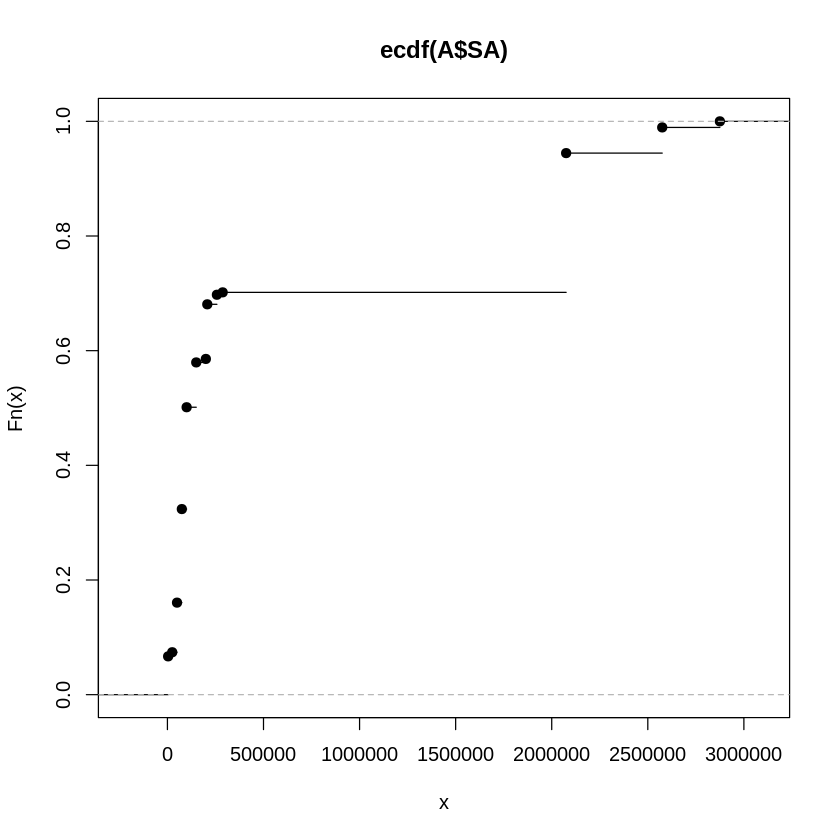

In [ ]:
summary(A$SA)
plot(ecdf(A$SA))

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 150000  705000  952000 1078074 1256000 4560000 

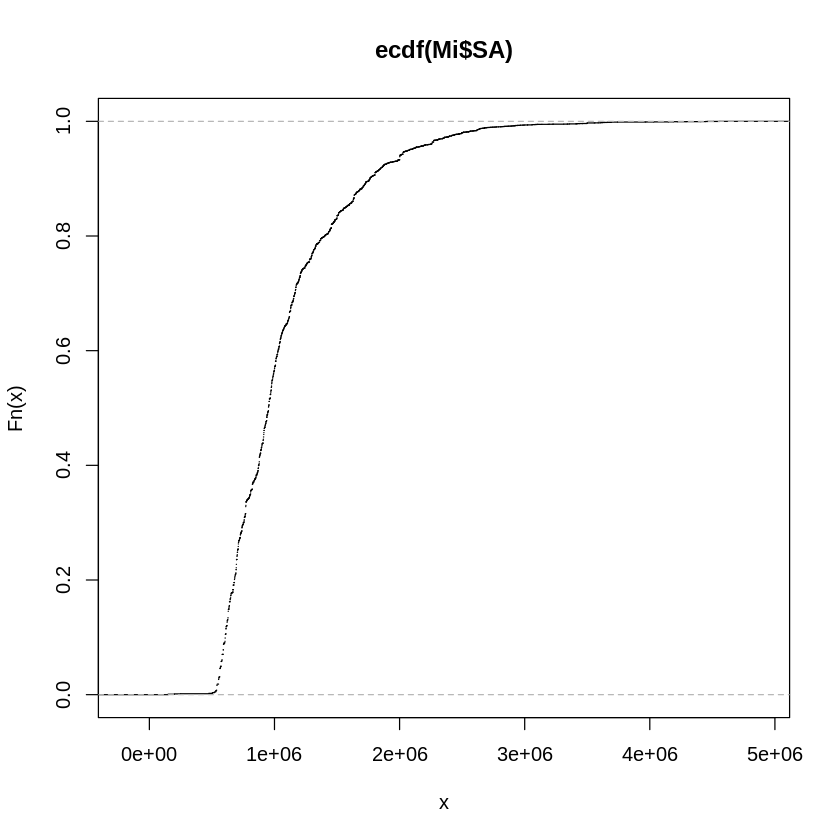

In [ ]:
summary(Mi$SA)
plot(ecdf(Mi$SA))

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
      25     3295     5876    47167    19760 36691536 

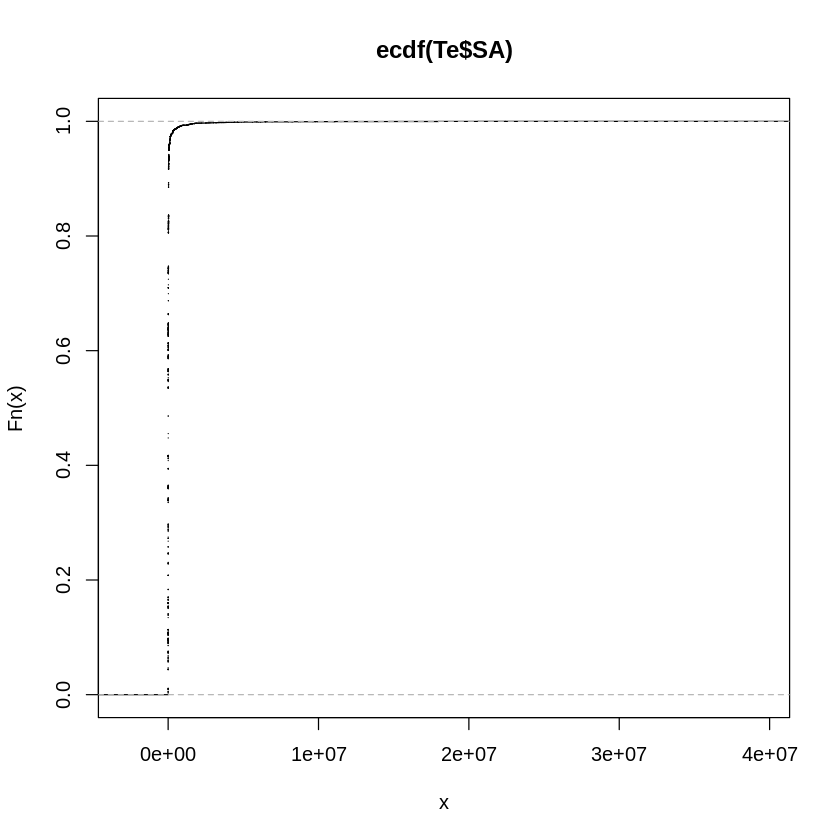

In [ ]:
summary(Te$SA)
plot(ecdf(Te$SA))

# Kolmogorov Smirnov

## **Accidentes** **Personales**

In [ ]:
#Accidentes personales
set.seed(1234)
e = fitdistr(A$SA,"lognormal")
x1 = e$estimate[1]
w1= e$estimate[2]
y1 = rlnorm(length(A$SA),x1,w1)
ks.test(y1,A$SA)


Warning message in ks.test.default(y1, A$SA):
“p-value will be approximate in the presence of ties”



	Asymptotic two-sample Kolmogorov-Smirnov test

data:  y1 and A$SA
D = 0.19507, p-value < 2.2e-16
alternative hypothesis: two-sided


In [ ]:
#Accidentes personales
set.seed(1234)
e = fitdistr(A$SA,"normal")
x2 = e$estimate[1]
w2= e$estimate[2]
y2 = rnorm(length(A$SA),x2,w2)
ks.test(y2,A$SA)

Warning message in ks.test.default(y2, A$SA):
“p-value will be approximate in the presence of ties”



	Asymptotic two-sample Kolmogorov-Smirnov test

data:  y2 and A$SA
D = 0.39127, p-value < 2.2e-16
alternative hypothesis: two-sided


In [ ]:
set.seed(1234)
#Accidentes personales
#e = fitdistr(A$SA,"gamma")
#x = e$estimate[1]
#y= e$estimate[2]
y3 = rgamma(length(A$SA),rate = 1/(var(A$SA)/mean(A$SA)),shape = (mean(A$SA))^2/var(A$SA))
ks.test(y3,A$SA)

Warning message in ks.test.default(y3, A$SA):
“p-value will be approximate in the presence of ties”



	Asymptotic two-sample Kolmogorov-Smirnov test

data:  y3 and A$SA
D = 0.3074, p-value < 2.2e-16
alternative hypothesis: two-sided


In [ ]:
B_1 = ecdf(A$SA)(seq(from=0, to=2000000, 2000))
B_2 = ecdf(y1)(seq(from=0, to=2000000, 2000))
C_2 = ecdf(y2)(seq(from=0, to=2000000, 2000))
D_2 = ecdf(y3)(seq(from=0, to=2000000, 2000))
# Crear data frames para cada comparación
pp_AB <- qq_data(B_1, B_2, "SA vs lognormal")
pp_AC <- qq_data(B_1, C_2, "SA vs normal")
pp_AD <- qq_data(B_1, D_2, "SA vs gamma")

# Unir todos los datos
pp_all <- bind_rows(pp_AB, pp_AC, pp_AD)

# Graficar con ggplot2
pp <- ggplot(pp_all, aes(x = x, y = y, color = grupo)) +
  geom_point() + geom_step() + coord_cartesian(ylim = c(0, 1)) +
  geom_abline(slope = 1, intercept = 0, linetype = "solid") +
  labs(title = "PP-Plot", x = "Probailidades de SA", y = "Probabilidades teóricas") +
  theme_minimal()



Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine




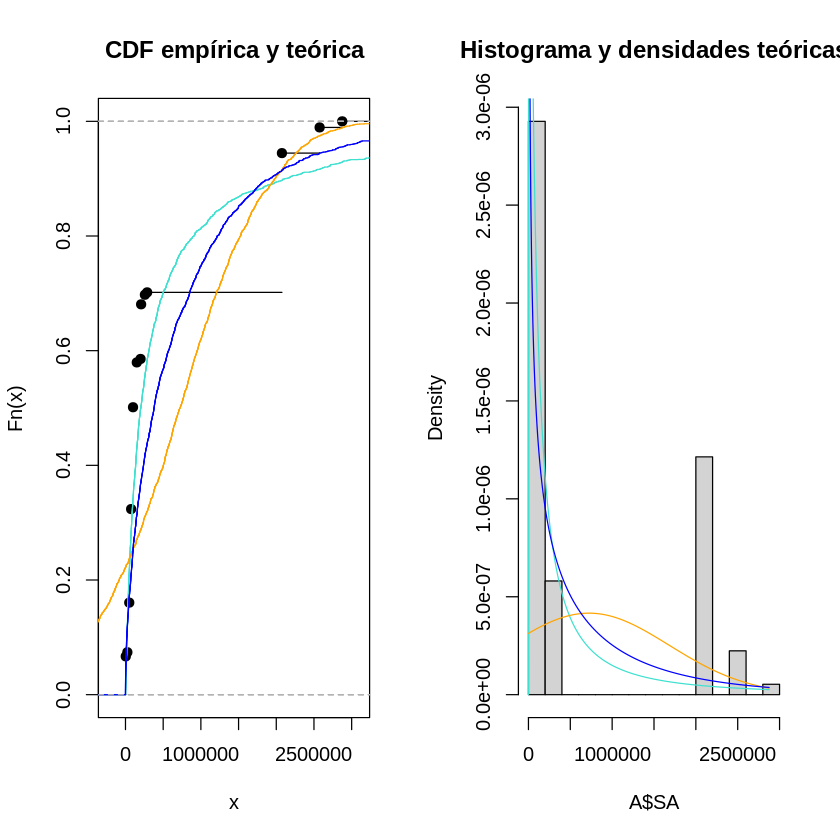

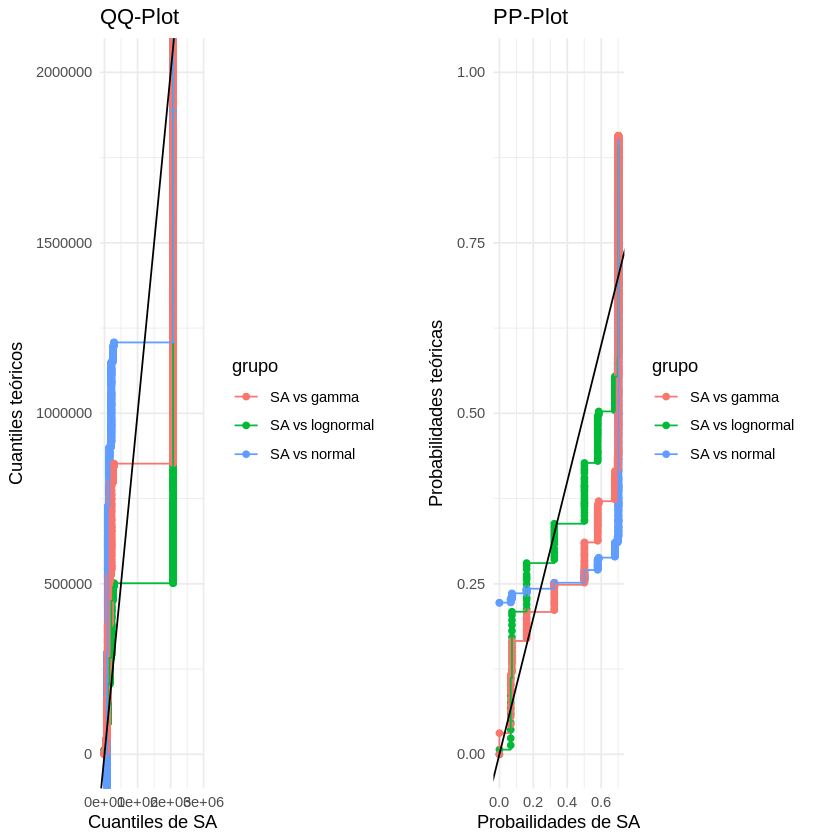

In [ ]:
par(mfrow = c(1,2))
plot(ecdf(A$SA), main = "CDF empírica y teórica")
lines(ecdf(y1), col = "turquoise")
lines(ecdf(y2), col = "orange")
lines(ecdf(y3), col = "blue")

hist(A$SA,freq = FALSE,main = "Histograma y densidades teóricas")
d = seq(from = 0, to = max(A$SA), by =1)
lines(d, dlnorm(d,x1,w1), col = "turquoise")
lines(d, dnorm(d,x2,w2), col = "orange")
lines(d, dgamma(d,rate = 1/(var(A$SA)/mean(A$SA)),shape = (mean(A$SA))^2/var(A$SA)), col = "blue")

A_1 = A$SA
B = y1
C = y2
D = y3
# Crear data frames para cada comparación
qq_AB <- qq_data(A_1, B, "SA vs lognormal")
qq_AC <- qq_data(A_1, C, "SA vs normal")
qq_AD <- qq_data(A_1, D, "SA vs gamma")

# Unir todos los datos
qq_all <- bind_rows(qq_AB, qq_AC, qq_AD)

# Graficar con ggplot2
p <- ggplot(qq_all, aes(x = x, y = y, color = grupo)) +
  geom_point() + geom_step() + coord_cartesian(ylim = c(0, 2000000)) +
  geom_abline(slope = 1, intercept = 0, linetype = "solid") +
  labs(title = "QQ-Plot", x = "Cuantiles de SA", y = "Cuantiles teóricos") +
  theme_minimal()
par(mfrow = c(1,1))
library(gridExtra)
grid.arrange(p, pp, ncol = 2)

## **Diversos** **Misceláneos**


In [ ]:
#Diversos Misceláneos
set.seed(1234)
e = fitdistr(Mi$SA,"lognormal")
x = e$estimate[1]
y= e$estimate[2]
y1 = rlnorm(length(Mi$SA),x,y)
ks.test(y1,Mi$SA)

Warning message in ks.test.default(y1, Mi$SA):
“p-value will be approximate in the presence of ties”



	Asymptotic two-sample Kolmogorov-Smirnov test

data:  y1 and Mi$SA
D = 0.06673, p-value < 2.2e-16
alternative hypothesis: two-sided


In [ ]:
#Diversos Misceláneos
set.seed(1234)
e = fitdistr(Mi$SA,"normal")
x = e$estimate[1]
y= e$estimate[2]
y2 = rnorm(length(Mi$SA),x,y)
ks.test(y2,Mi$SA)

Warning message in ks.test.default(y2, Mi$SA):
“p-value will be approximate in the presence of ties”



	Asymptotic two-sample Kolmogorov-Smirnov test

data:  y2 and Mi$SA
D = 0.14836, p-value < 2.2e-16
alternative hypothesis: two-sided


In [ ]:
#Diversos Misceláneos
set.seed(1234)
y3 = rgamma(length(Mi$SA),rate = 1/(var(Mi$SA)/mean(Mi$SA)),shape = (mean(Mi$SA))^2/var(Mi$SA))
ks.test(y3,Mi$SA)

Warning message in ks.test.default(y3, Mi$SA):
“p-value will be approximate in the presence of ties”



	Asymptotic two-sample Kolmogorov-Smirnov test

data:  y3 and Mi$SA
D = 0.11543, p-value < 2.2e-16
alternative hypothesis: two-sided


In [ ]:
B_1 = ecdf(Mi$SA)(seq(from=0, to=4500000, 4000))
B_2 = ecdf(y1)(seq(from=0, to=4500000, 4000))
C_2 = ecdf(y2)(seq(from=0, to=4500000, 4000))
D_2 = ecdf(y3)(seq(from=0, to=4500000, 4000))
# Crear data frames para cada comparación
pp_AB <- qq_data(B_1, B_2, "SA vs lognormal")
pp_AC <- qq_data(B_1, C_2, "SA vs normal")
pp_AD <- qq_data(B_1, D_2, "SA vs gamma")

# Unir todos los datos
pp_all <- bind_rows(pp_AB, pp_AC, pp_AD)

# Graficar con ggplot2
pp <- ggplot(pp_all, aes(x = x, y = y, color = grupo)) +
  geom_point() + geom_step() + coord_cartesian(ylim = c(0, 1)) +
  geom_abline(slope = 1, intercept = 0, linetype = "solid") +
  labs(title = "PP-Plot", x = "Probailidades de SA", y = "Probabilidades teóricas") +
  theme_minimal()


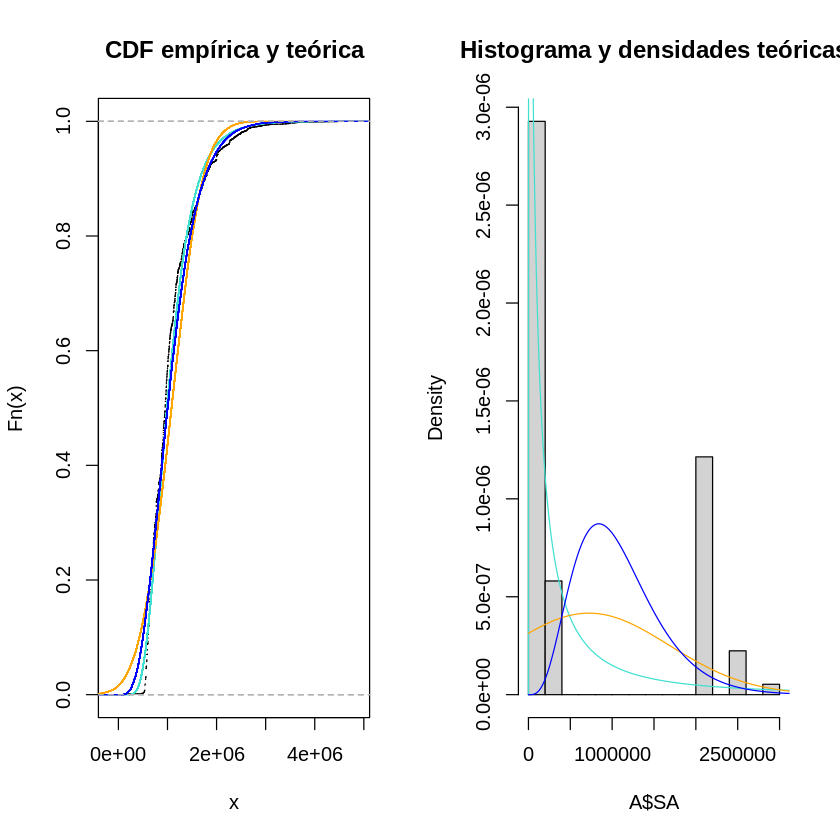

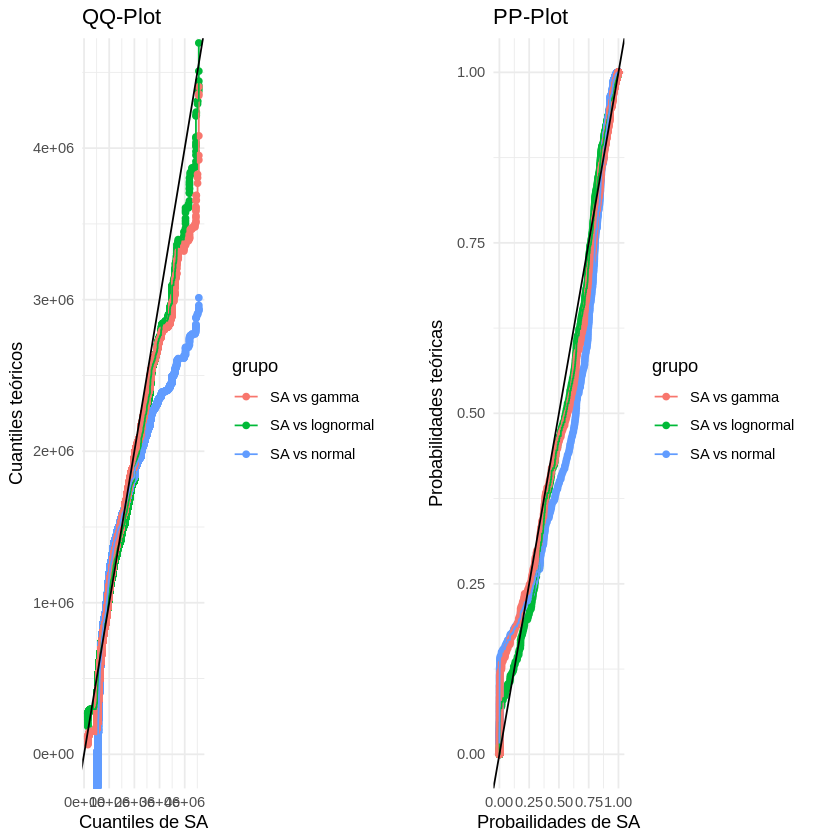

In [ ]:
par(mfrow = c(1,2))
plot(ecdf(Mi$SA), main = "CDF empírica y teórica")
lines(ecdf(y1), col = "turquoise")
lines(ecdf(y2), col = "orange")
lines(ecdf(y3), col = "blue")

hist(A$SA,freq = FALSE,main = "Histograma y densidades teóricas")
d = seq(from = 0, to = max(Mi$SA), by =1)
lines(d, dlnorm(d,x1,w1), col = "turquoise")
lines(d, dnorm(d,x2,w2), col = "orange")
lines(d, dgamma(d,rate = 1/(var(Mi$SA)/mean(Mi$SA)),shape = (mean(Mi$SA))^2/var(Mi$SA)), col = "blue")

A_1 = Mi$SA
B = y1
C = y2
D = y3
# Crear data frames para cada comparación
qq_AB <- qq_data(A_1, B, "SA vs lognormal")
qq_AC <- qq_data(A_1, C, "SA vs normal")
qq_AD <- qq_data(A_1, D, "SA vs gamma")

# Unir todos los datos
qq_all <- bind_rows(qq_AB, qq_AC, qq_AD)

# Graficar con ggplot2
p <- ggplot(qq_all, aes(x = x, y = y, color = grupo)) +
  geom_point() + geom_step() + coord_cartesian(ylim = c(0, 4500000)) +
  geom_abline(slope = 1, intercept = 0, linetype = "solid") +
  labs(title = "QQ-Plot", x = "Cuantiles de SA", y = "Cuantiles teóricos") +
  theme_minimal()
par(mfrow = c(1,1))
library(gridExtra)
grid.arrange(p, pp, ncol = 2)

## **Diversos** **Técnicos**

In [ ]:
#Diversos Técnicos
set.seed(1234)
e = fitdistr(Te$SA,"lognormal")
x = e$estimate[1]
y= e$estimate[2]
y1 = rlnorm(length(Te$SA),x,y)
ks.test(y1,Te$SA)

Warning message in ks.test.default(y1, Te$SA):
“p-value will be approximate in the presence of ties”



	Asymptotic two-sample Kolmogorov-Smirnov test

data:  y1 and Te$SA
D = 0.11175, p-value < 2.2e-16
alternative hypothesis: two-sided


In [ ]:
#Diversos Técnicos
set.seed(1234)
e = fitdistr(Te$SA,"normal")
x = e$estimate[1]
y= e$estimate[2]
y2 = rnorm(length(Te$SA),x,y)
ks.test(y2,Te$SA)

Warning message in ks.test.default(y2, Te$SA):
“p-value will be approximate in the presence of ties”



	Asymptotic two-sample Kolmogorov-Smirnov test

data:  y2 and Te$SA
D = 0.46226, p-value < 2.2e-16
alternative hypothesis: two-sided


In [ ]:
#Diversos Técnicos
set.seed(1234)
y3 = rgamma(length(Te$SA),rate = 1/(var(Te$SA)/mean(Te$SA)),shape = (mean(Te$SA))^2/var(Te$SA))
ks.test(y3,Te$SA)

Warning message in ks.test.default(y3, Te$SA):
“p-value will be approximate in the presence of ties”



	Asymptotic two-sample Kolmogorov-Smirnov test

data:  y3 and Te$SA
D = 0.91333, p-value < 2.2e-16
alternative hypothesis: two-sided


In [ ]:
B_1 = ecdf(Te$SA)(seq(from=0, to=36000000, 1000))
B_2 = ecdf(y1)(seq(from=0, to=36000000, 1000))
C_2 = ecdf(y2)(seq(from=0, to=36000000, 1000))
D_2 = ecdf(y3)(seq(from=0, to=36000000, 1000))
# Crear data frames para cada comparación
pp_AB <- qq_data(B_1, B_2, "SA vs lognormal")
pp_AC <- qq_data(B_1, C_2, "SA vs normal")
pp_AD <- qq_data(B_1, D_2, "SA vs gamma")

# Unir todos los datos
pp_all <- bind_rows(pp_AB, pp_AC, pp_AD)

# Graficar con ggplot2
pp <- ggplot(pp_all, aes(x = x, y = y, color = grupo)) +
  geom_point() + geom_step() + coord_cartesian(ylim = c(0, 1)) +
  geom_abline(slope = 1, intercept = 0, linetype = "solid") +
  labs(title = "PP-Plot", x = "Probailidades de SA", y = "Probabilidades teóricas") +
  theme_minimal()


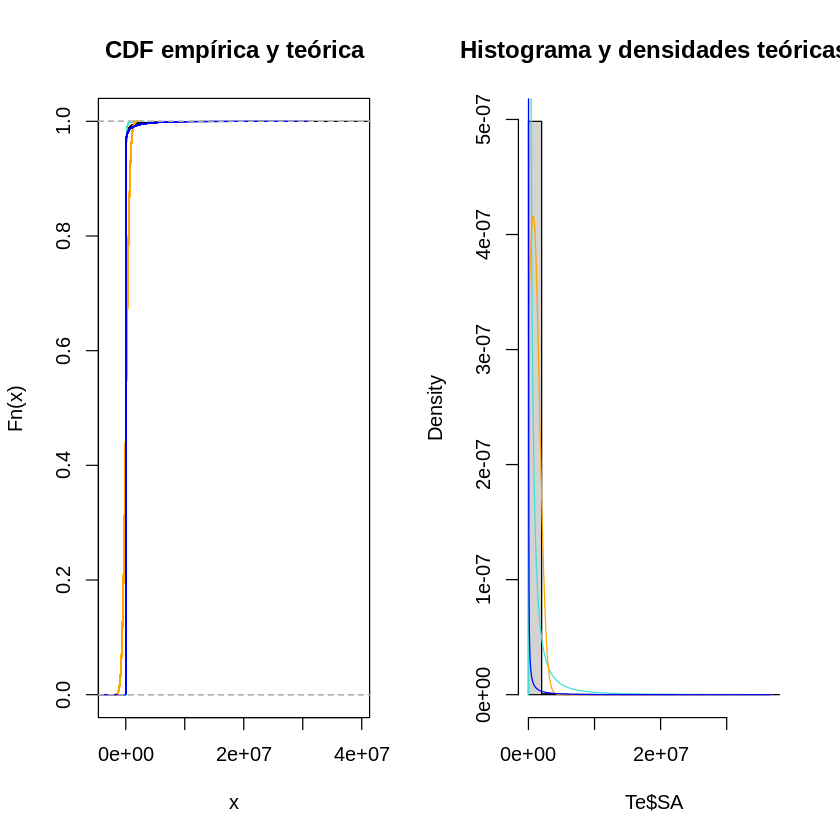

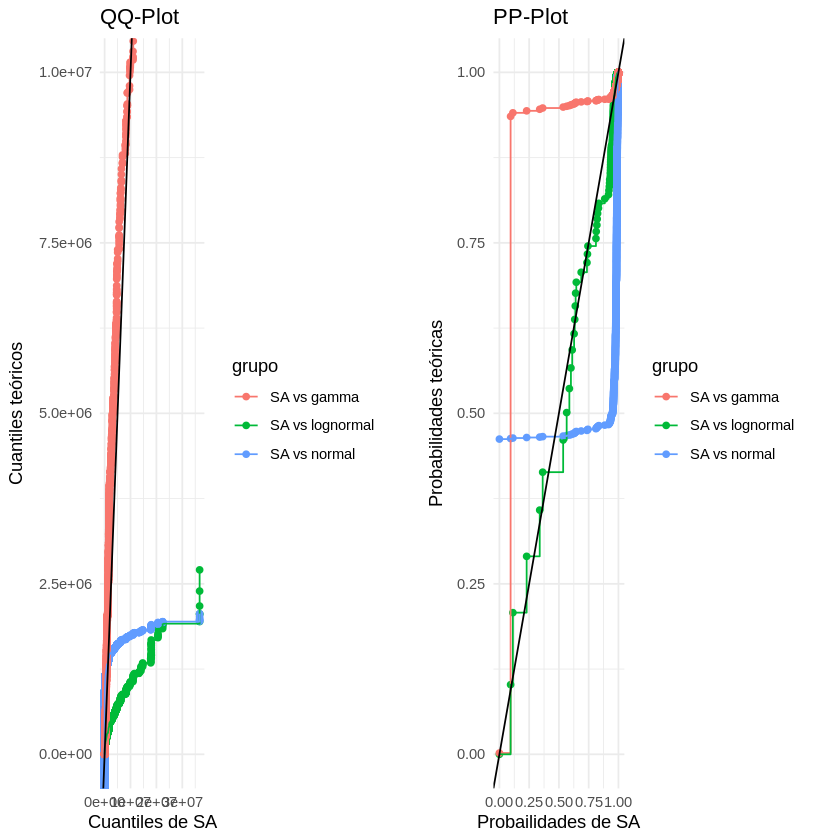

In [ ]:
par(mfrow = c(1,2))
plot(ecdf(Te$SA), main = "CDF empírica y teórica")
lines(ecdf(y1), col = "turquoise")
lines(ecdf(y2), col = "orange")
lines(ecdf(y3), col = "blue")

hist(Te$SA,freq = FALSE,main = "Histograma y densidades teóricas")
d = seq(from = 0, to = max(Te$SA), 3600)
lines(d, dlnorm(d,x1,w1), col = "turquoise")
lines(d, dnorm(d,x2,w2), col = "orange")
lines(d, dgamma(d,rate = 1/(var(Te$SA)/mean(Te$SA)),shape = (mean(Te$SA))^2/var(Te$SA)), col = "blue")

A_1 = Te$SA
B = y1
C = y2
D = y3
# Crear data frames para cada comparación
qq_AB <- qq_data(A_1, B, "SA vs lognormal")
qq_AC <- qq_data(A_1, C, "SA vs normal")
qq_AD <- qq_data(A_1, D, "SA vs gamma")

# Unir todos los datos
qq_all <- bind_rows(qq_AB, qq_AC, qq_AD)

# Graficar con ggplot2
p <- ggplot(qq_all, aes(x = x, y = y, color = grupo)) +
  geom_point() + geom_step() + coord_cartesian(ylim = c(0, 10000000)) +
  geom_abline(slope = 1, intercept = 0, linetype = "solid") +
  labs(title = "QQ-Plot", x = "Cuantiles de SA", y = "Cuantiles teóricos") +
  theme_minimal()
par(mfrow = c(1,1))
library(gridExtra)
grid.arrange(p, pp, ncol = 2)

# Cramer-von Mises


## **Accidentes** **Personales**

In [ ]:
# Accidentes personales
cv = cvm.test(A$SA,  null = "plnorm",  meanlog = mean(A$SA),  sdlog = sd(A$SA))
cv


	Cramer-von Mises test of goodness-of-fit
	Null hypothesis: log-normal distribution
	with parameters meanlog = 722812.144212524, sdlog = 958589.812401614
	Parameters assumed to be fixed

data:  A$SA
omega2 = 418.25, p-value < 2.2e-16


In [ ]:
# Accidentes personales
cv = cvm.test(A$SA,  null = "norm",  mean = mean(A$SA),  sd = sd(A$SA))
cv


	Cramer-von Mises test of goodness-of-fit
	Null hypothesis: Normal distribution
	with parameters mean = 722812.144212524, sd = 958589.812401614
	Parameters assumed to be fixed

data:  A$SA
omega2 = 85.992, p-value < 2.2e-16


In [ ]:
# Accidentes personales
cv = cvm.test(A$SA,  null = "gamma",  rate = 1/(var(A$SA)/mean(A$SA)),shape = (mean(A$SA))^2/var(A$SA))
cv


	Cramer-von Mises test of goodness-of-fit
	Null hypothesis: Gamma distribution
	with parameters rate = 7.86610650626655e-07, shape = 0.568571731039861
	Parameters assumed to be fixed

data:  A$SA
omega2 = 54.631, p-value < 2.2e-16


In [ ]:
cv$statistic

omega2 
54.63094

### Comentario

In [ ]:
library(MASS)
library(goftest)
library(fitdistrplus)
e = fitdistr(A$SA,"lognormal")
#cv2 = cvm.test(x, "pnorm", mean=2, sd=1)
cv2 = cvm.test(A$SA, "plnorm",  e$estimate["meanlog"],  e$estimate["sdlog"])
cv2


	Cramer-von Mises test of goodness-of-fit
	Null hypothesis: log-normal distribution
	Parameters assumed to be fixed

data:  A$SA
omega2 = 23.278, p-value < 2.2e-16


In [ ]:
cv2$statistic

omega2 
23.27823

## **Diversos** **Misceláneos**

In [ ]:
#Diversos Misceláneos
cv = cvm.test(Mi$SA,  null = "plnorm",  meanlog = mean(Mi$SA),  sdlog = sd(Mi$SA))
cv


	Cramer-von Mises test of goodness-of-fit
	Null hypothesis: log-normal distribution
	with parameters meanlog = 1078074.07402404, sdlog = 505644.714589656
	Parameters assumed to be fixed

data:  Mi$SA
omega2 = 14085, p-value < 2.2e-16


In [ ]:
#Diversos Misceláneos
cv = cvm.test(Mi$SA,  null = "norm",  mean = mean(Mi$SA),  sd = sd(Mi$SA))
cv


	Cramer-von Mises test of goodness-of-fit
	Null hypothesis: Normal distribution
	with parameters mean = 1078074.07402404, sd = 505644.714589656
	Parameters assumed to be fixed

data:  Mi$SA
omega2 = 315.44, p-value < 2.2e-16


In [ ]:
#Diversos Misceláneos
cv = cvm.test(Mi$SA,  null = "gamma",  rate = 1/(var(Mi$SA)/mean(Mi$SA)),shape = (mean(Mi$SA))^2/var(Mi$SA))
cv


	Cramer-von Mises test of goodness-of-fit
	Null hypothesis: Gamma distribution
	with parameters rate = 4.21655391752697e-06, shape = 4.54575746021035
	Parameters assumed to be fixed

data:  Mi$SA
omega2 = 114.27, p-value < 2.2e-16


# Anderson-Darling




## **Accidentes** **personales**

In [ ]:
#Accidentes personales
ad.test(Mi$SA, "plnorm",  meanlog = mean(A$SA),  sdlog = sd(A$SA))


	Anderson-Darling test of goodness-of-fit
	Null hypothesis: log-normal distribution
	with parameters meanlog = 722812.144212524, sdlog = 958589.812401614
	Parameters assumed to be fixed

data:  Mi$SA
An = 33102, p-value = 1.351e-08


In [ ]:
#Accidentes personales
ad.test(A$SA, "norm",  mean = mean(A$SA),  sd = sd(A$SA))


	Anderson-Darling test of goodness-of-fit
	Null hypothesis: Normal distribution
	with parameters mean = 722812.144212524, sd = 958589.812401614
	Parameters assumed to be fixed

data:  A$SA
An = 459.55, p-value = 2.277e-07


In [ ]:
#Accidentes personales
ad.test(A$SA, "gamma",  rate = 1/(var(A$SA)/mean(A$SA)),shape = (mean(A$SA))^2/var(A$SA))


	Anderson-Darling test of goodness-of-fit
	Null hypothesis: Gamma distribution
	with parameters rate = 7.86610650626655e-07, shape = 0.568571731039861
	Parameters assumed to be fixed

data:  A$SA
An = 284.89, p-value = 2.277e-07


## **Diversos** **Miscelaneos**

In [ ]:
#Diversos Misceláneos
cv = ad.test(Mi$SA,  null = "plnorm",  meanlog = mean(Mi$SA),  sdlog = sd(Mi$SA))
cv


	Anderson-Darling test of goodness-of-fit
	Null hypothesis: log-normal distribution
	with parameters meanlog = 1078074.07402404, sdlog = 505644.714589656
	Parameters assumed to be fixed

data:  Mi$SA
An = 138626, p-value = 1.351e-08


In [ ]:
#Diversos Misceláneos
cv = ad.test(Mi$SA,  null = "norm",  mean = mean(Mi$SA),  sd = sd(Mi$SA))
cv


	Anderson-Darling test of goodness-of-fit
	Null hypothesis: Normal distribution
	with parameters mean = 1078074.07402404, sd = 505644.714589656
	Parameters assumed to be fixed

data:  Mi$SA
An = 1821.4, p-value = 1.351e-08


In [ ]:
#Diversos Misceláneos
cv = ad.test(Mi$SA,  null = "gamma",  rate = 1/(var(Mi$SA)/mean(Mi$SA)),shape = (mean(Mi$SA))^2/var(Mi$SA))
cv


	Anderson-Darling test of goodness-of-fit
	Null hypothesis: Gamma distribution
	with parameters rate = 4.21655391752697e-06, shape = 4.54575746021035
	Parameters assumed to be fixed

data:  Mi$SA
An = 813.43, p-value = 1.351e-08


## **Diversos** **Técnicos**

In [ ]:
#Diversos Misceláneos
cv = ad.test(Te$SA,  null = "plnorm",  meanlog = mean(Te$SA),  sdlog = sd(Te$SA))
cv


	Anderson-Darling test of goodness-of-fit
	Null hypothesis: log-normal distribution
	with parameters meanlog = 47167.4265655628, sdlog = 515819.416538716
	Parameters assumed to be fixed

data:  Te$SA
An = 51432, p-value = 4.569e-09


In [ ]:
#Diversos Misceláneos
cv = ad.test(Te$SA,  null = "plnorm",  meanlog = mean(Te$SA),  sdlog = sd(Te$SA))
cv


	Anderson-Darling test of goodness-of-fit
	Null hypothesis: log-normal distribution
	with parameters meanlog = 47167.4265655628, sdlog = 515819.416538716
	Parameters assumed to be fixed

data:  Te$SA
An = 51432, p-value = 4.569e-09


In [ ]:
#Diversos Misceláneos
cv = ad.test(Te$SA,  null = "plnorm",  meanlog = mean(Te$SA),  sdlog = sd(Te$SA))
cv


	Anderson-Darling test of goodness-of-fit
	Null hypothesis: log-normal distribution
	with parameters meanlog = 47167.4265655628, sdlog = 515819.416538716
	Parameters assumed to be fixed

data:  Te$SA
An = 51432, p-value = 4.569e-09


# Método Original

In [ ]:
#Nuevamente se cargan
#Una vez importados se quitan valores ausentes
B = subset(Vigor, !is.na(Vigor$POL))
unique(B$SUBR)
#Se toma diversos miscelaneos
A = B%>%filter(B$RMO == 30 & B$SUBR == 33 & B$Tipo_endoso != "D" & B$SA>0)
Mi = B%>%filter(B$RMO == 110 & B$SUBR == 111 & B$Tipo_endoso != "D" & B$SA>0)
Te = B%>%filter(B$RMO == 110 & B$SUBR == 112 & B$Tipo_endoso != "D" & B$SA>0)

[1] 112 111  33

## Accidentes Personales

In [ ]:
set.seed(1234)
M = A$SA
LMR = 2000000
longitud = length(M)
ajuste = fitdistr(M,"lognormal")
e1  = ajuste$estimate[1]
e2  = ajuste$estimate[2]
z = rlnorm(longitud, meanlog = e1, sdlog = e2)
z1 = z-LMR
length(which(z1>0))*100/longitud

[1] 10.62619

## Diversos Misceláneos

In [ ]:
set.seed(1234)
M = Mi$SA
LMR = 6000000
longitud = length(M)
ajuste = fitdistr(M,"lognormal")
e1  = ajuste$estimate[1]
e2  = ajuste$estimate[2]
z = rlnorm(longitud, meanlog = e1, sdlog = e2)
z1 = z-LMR
length(which(z1>0))*100/longitud

[1] 0

## Diversos Técnicos

In [ ]:
set.seed(1234)
M = Te$SA
LMR = 10000000
longitud = length(M)
ajuste = fitdistr(M,"lognormal")
e1  = ajuste$estimate[1]
e2  = ajuste$estimate[2]
z = rlnorm(longitud, meanlog = e1, sdlog = e2)
z1 = z-LMR
length(which(z1>0))*100/longitud

[1] 0

# Nuevo Método

## **Accidentes personales**

In [ ]:
#Nuevamente se cargan
#Una vez importados se quitan valores ausentes
B = subset(Vigor, !is.na(Vigor$POL))
unique(B$SUBR)
#Actualización bases
A = B%>%filter(B$RMO == 30 & B$SUBR == 33 & B$Tipo_endoso != "D" & B$SA>0)
Mi = B%>%filter(B$RMO == 110 & B$SUBR == 111 & B$Tipo_endoso != "D" & B$SA>0)
Te = B%>%filter(B$RMO == 110 & B$SUBR == 112 & B$Tipo_endoso != "D" & B$SA>0)

[1] 112 111  33

In [ ]:
M = A$SA
#Se aplica una transformación de Box Cox para suavizar los datos
#Posteriormente esto puede deshacerse
M = M^(1/2.07)

### **Ajuste**

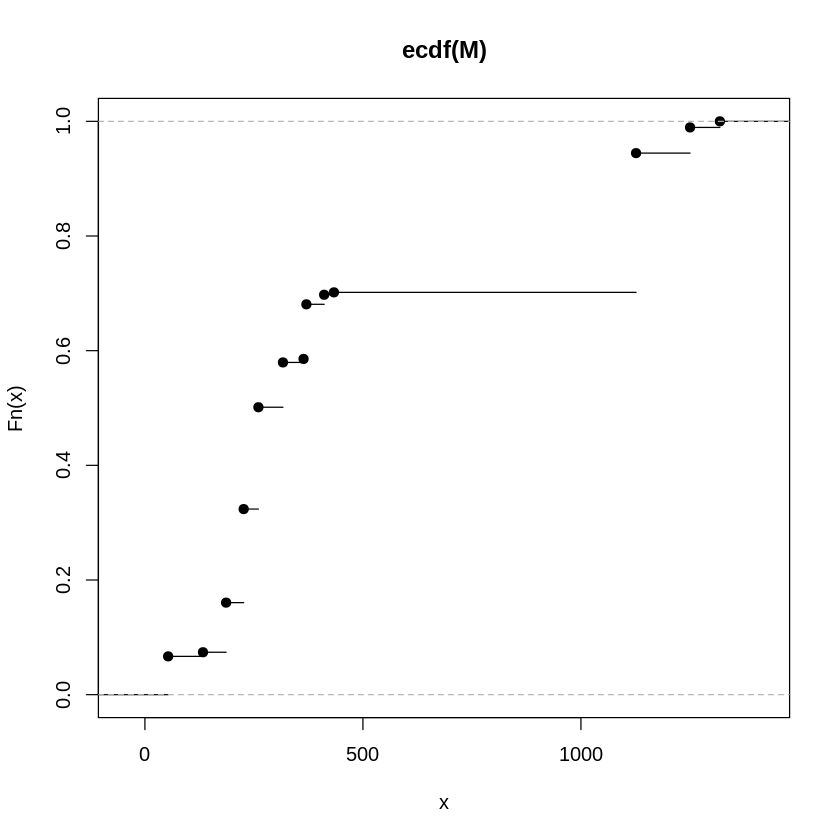

In [ ]:
plot(ecdf(M))

In [ ]:
#Se calculan los whiscklers del box plot y se quitan outliers
l =  boxplot.stats(M)$stats
M= M[M >= l[1] & M <= l[5]]
summary(M)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  53.28  226.52  260.29  518.33 1126.42 1318.61 

In [ ]:
#Se calcula por máxima verosimilitud los parámetros de una cauchy
ajuste = fitdistr(M,"cauchy")
ajuste
#Se guardan los degree freedom en la variable m
m = ajuste$estimate["location"]
m1 = ajuste$estimate["scale"]
set.seed(1234)
y <- rcauchy(length(M),location=m, scale = m1)
#Se comparan nuestros datos con la simulación
#La hipótesis alternativa es que la función de distribución o de proabilidad acumulada empírica queda por encima de
ks.test(M,y, alternative = "greater")

Warning message in densfun(x, parm[1], parm[2], ...):
“NaNs produced”
Warning message in densfun(x, parm[1], parm[2], ...):
“NaNs produced”
Warning message in densfun(x, parm[1], parm[2], ...):
“NaNs produced”
Warning message in densfun(x, parm[1], parm[2], ...):
“NaNs produced”
Warning message in densfun(x, parm[1], parm[2], ...):
“NaNs produced”
Warning message in densfun(x, parm[1], parm[2], ...):
“NaNs produced”
Warning message in densfun(x, parm[1], parm[2], ...):
“NaNs produced”
Warning message in densfun(x, parm[1], parm[2], ...):
“NaNs produced”
Warning message in densfun(x, parm[1], parm[2], ...):
“NaNs produced”
Warning message in densfun(x, parm[1], parm[2], ...):
“NaNs produced”
Warning message in densfun(x, parm[1], parm[2], ...):
“NaNs produced”


    location      scale   
  261.171517    94.802395 
 (  2.424647) (  3.075179)

Warning message in ks.test.default(M, y, alternative = "greater"):
“p-value will be approximate in the presence of ties”



	Asymptotic two-sample Kolmogorov-Smirnov test

data:  M and y
D^+ = 0.027704, p-value = 0.1323
alternative hypothesis: the CDF of x lies above that of y


### **Gráficos**

Warning message in segments(ti.l, y, ti.r, y, col = col.hor, lty = lty, lwd = lwd, :
“graphical parameter "type" is obsolete”


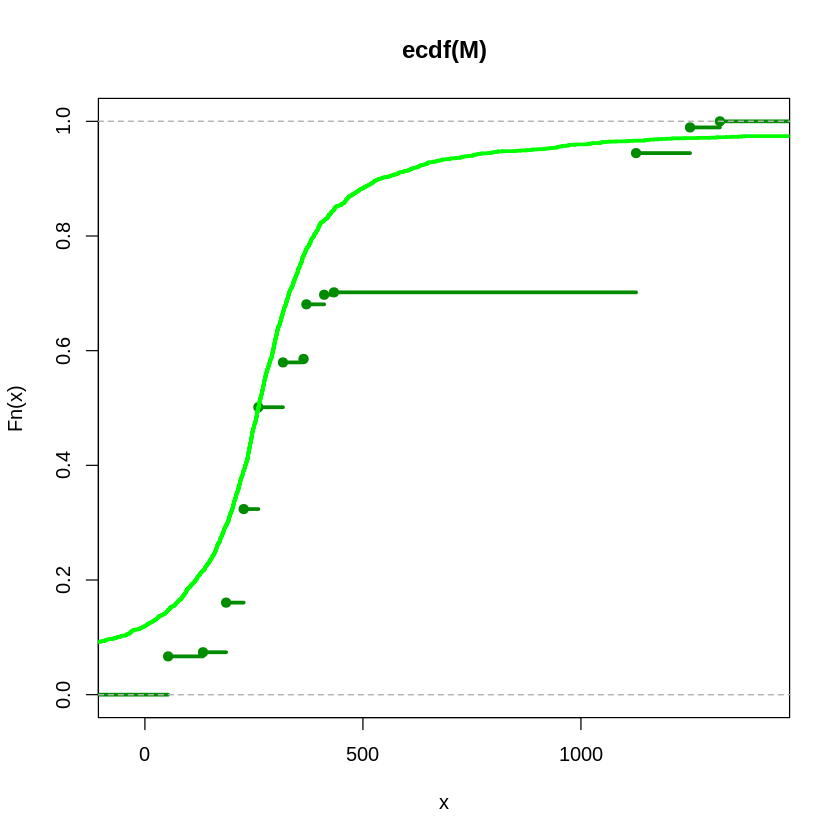

In [ ]:
plot(ecdf(M),col = "green4",lwd = 3)
lines(ecdf(y),lwd = 3,type = "s", col = "green")

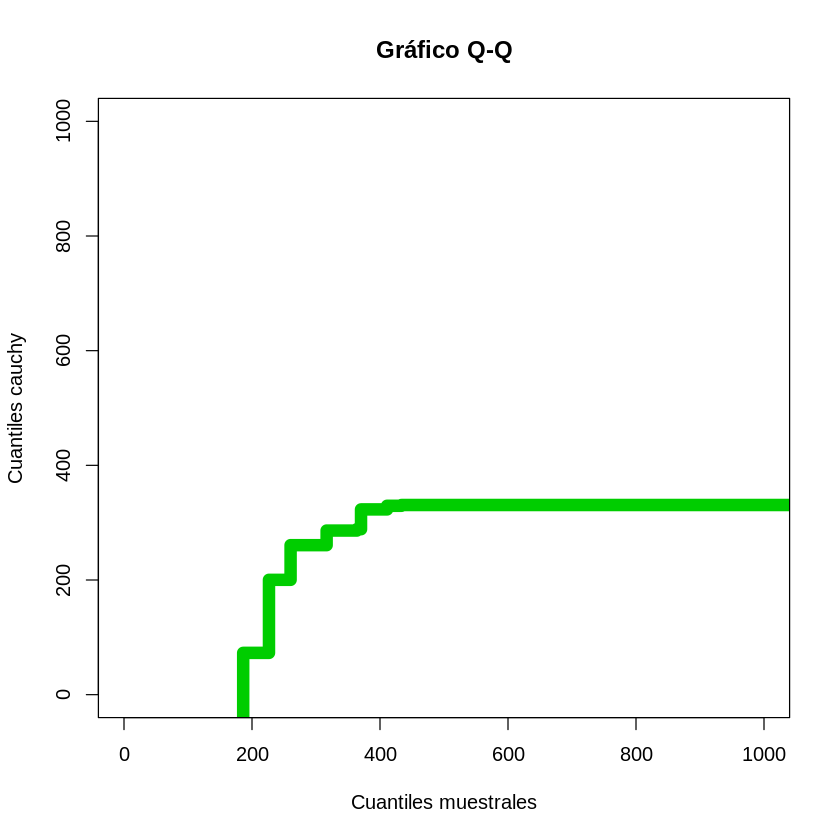

In [ ]:
qqplot(M,y,xlim = c(0,1000), ylim = c(0,1000), col = "green3", ylab = "Cuantiles cauchy", xlab = "Cuantiles muestrales", main = "Gráfico Q-Q",type = "s",lwd = 10,)


In [ ]:
## Prueba

In [ ]:
f = function(x){
  #p = unique(M)
  y = length(which(M <= x))/length(M)
  return(y)
}

In [ ]:
f(1500000)

[1] 1

In [ ]:
set.seed(1234)
longitud = 10000000
c = rcauchy(longitud, m, m1)
c = c[c>0]
SA = list()
for(i in 1:length(c)){
  u = runif(1, 0, dcauchy(c[i],m, m1))
  if(u*c[i] <= f(c[i])){
    SA[[i]] =  c[i]
  }
}
SA = unlist(SA)

In [ ]:
length(SA)

[1] 5679942

In [ ]:
LMR = 2000000
z = SA
z = z^(2.07)
summary(z)

In [ ]:
boxplot(z)

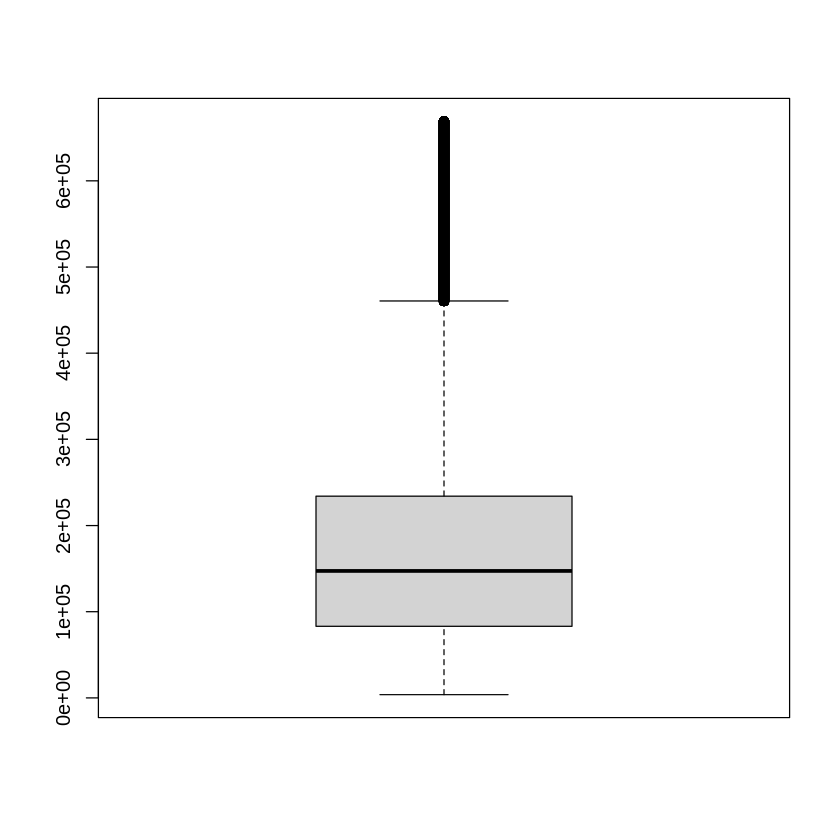

In [ ]:
#Quitamos valores atípicos
l1 =  boxplot.stats(z)$stats
z= z[z >= l1[1] & z <= l1[5]]
boxplot(z)

In [ ]:
summary(z)
length(z)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   3750   83080  147333  177158  234091  669053 

[1] 4923996

In [ ]:
z1 = z -LMR
summary(z1)

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
-1996250 -1916920 -1852667 -1822842 -1765909 -1330947 

In [ ]:
length(which(z1>0))*100/length(SA)

[1] 0

## Sensibilidad a incrementar la suma asegurada

In [ ]:
prueba = function(i,LMR,z){
  k = z^(2.07)
  k = (1+i)*k
  z1 = k-LMR
  f = length(which(z1>0))/length(z1)
  return(f)
}

In [ ]:
library(ggplot2)
LMR = 1000000
d2 = seq ( from = 0, to = 1, by = 1/ 100)
escenarios = sapply (d2 , prueba , LMR = LMR, z=z )
# Datos de ejemplo
sensibilidad <- data.frame(
  incremento = d2,
  porcentaje = escenarios,
  categoria = c(1:length(escenarios))
)

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


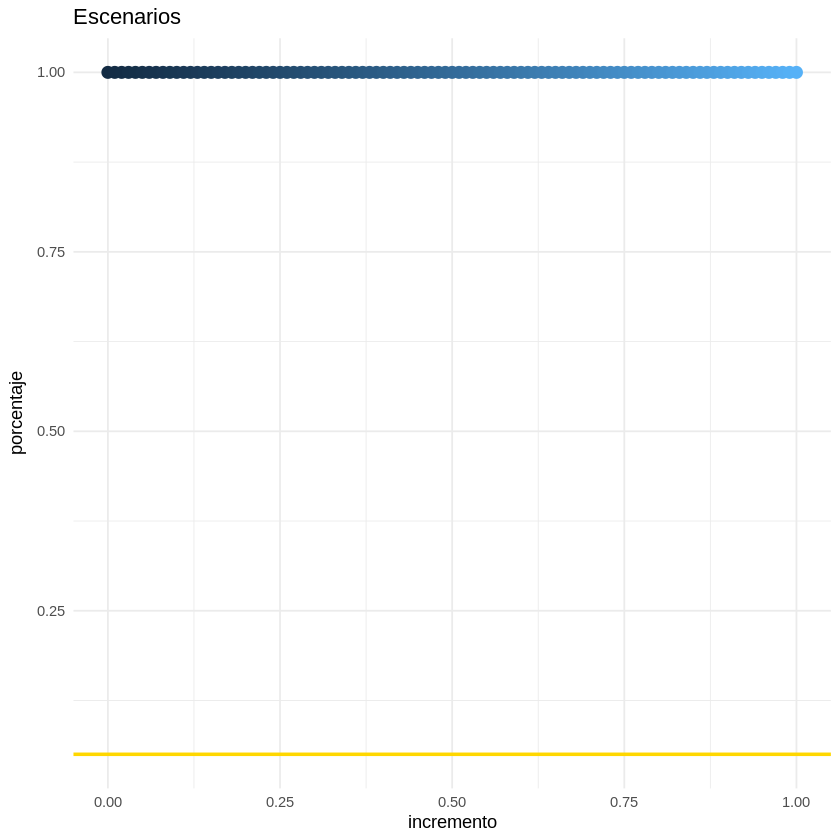

In [ ]:
# Scatter plot
ggplot(sensibilidad, aes(x = incremento, y = porcentaje, color = categoria)) +
  geom_point(size = 3) +
  labs(title = "Escenarios") +
  theme_minimal()+theme(legend.position = "none") +
  geom_hline(yintercept = .05, color = "gold", linetype = "solid", size = 1)

# **Diversos Misceláneos**

In [ ]:
M = Mi$SA
#Se aplica una transformación de Box Cox para suavizar los datos
#Posteriormente esto puede deshacerse
M = log(M)-12

In [ ]:
#Se calculan los whiscklers del box plot y se quitan outliers
l =  boxplot.stats(M)$stats
M= M[M >= l[1] & M <= l[5]]
summary(M)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  1.071   1.466   1.766   1.796   2.035   2.909 

In [ ]:
#Se calcula por máxima verosimilitud los parámetros de una cauchy
ajuste = fitdistr(M,"t")
ajuste
#Se guardan los degree freedom en la variable m
m = ajuste$estimate["df"]
set.seed(1234)
y <- rt(length(M),df =m)
#Se comparan nuestros datos con la simulación
#La hipótesis alternativa es que la función de distribución o de proabilidad acumulada empírica queda por encima de
ks.test(M,y, alternative = "greater")

Warning message in dt((x - m)/s, df, log = TRUE):
“NaNs produced”
Warning message in dt((x - m)/s, df, log = TRUE):
“NaNs produced”
Warning message in log(s):
“NaNs produced”
Warning message in log(s):
“NaNs produced”
Warning message in log(s):
“NaNs produced”
Warning message in log(s):
“NaNs produced”
Warning message in log(s):
“NaNs produced”
Warning message in log(s):
“NaNs produced”
Warning message in log(s):
“NaNs produced”
Warning message in log(s):
“NaNs produced”
Warning message in log(s):
“NaNs produced”
Warning message in log(s):
“NaNs produced”
Warning message in log(s):
“NaNs produced”
Warning message in log(s):
“NaNs produced”
Warning message in log(s):
“NaNs produced”
Warning message in log(s):
“NaNs produced”
Warning message in log(s):
“NaNs produced”
Warning message in log(s):
“NaNs produced”
Warning message in log(s):
“NaNs produced”
Warning message in log(s):
“NaNs produced”
Warning message in log(s):
“NaNs produced”
Warning message in log(s):
“NaNs produced”
Warning 

        m              s              df     
  1.795423e+00   3.888372e-01   3.536664e+02 
 (1.861325e-03) (1.325914e-03) (6.955158e+01)

Warning message in ks.test.default(M, y, alternative = "greater"):
“p-value will be approximate in the presence of ties”



	Asymptotic two-sample Kolmogorov-Smirnov test

data:  M and y
D^+ = 0.0018387, p-value = 0.8616
alternative hypothesis: the CDF of x lies above that of y


Warning message in segments(ti.l, y, ti.r, y, col = col.hor, lty = lty, lwd = lwd, :
“graphical parameter "type" is obsolete”


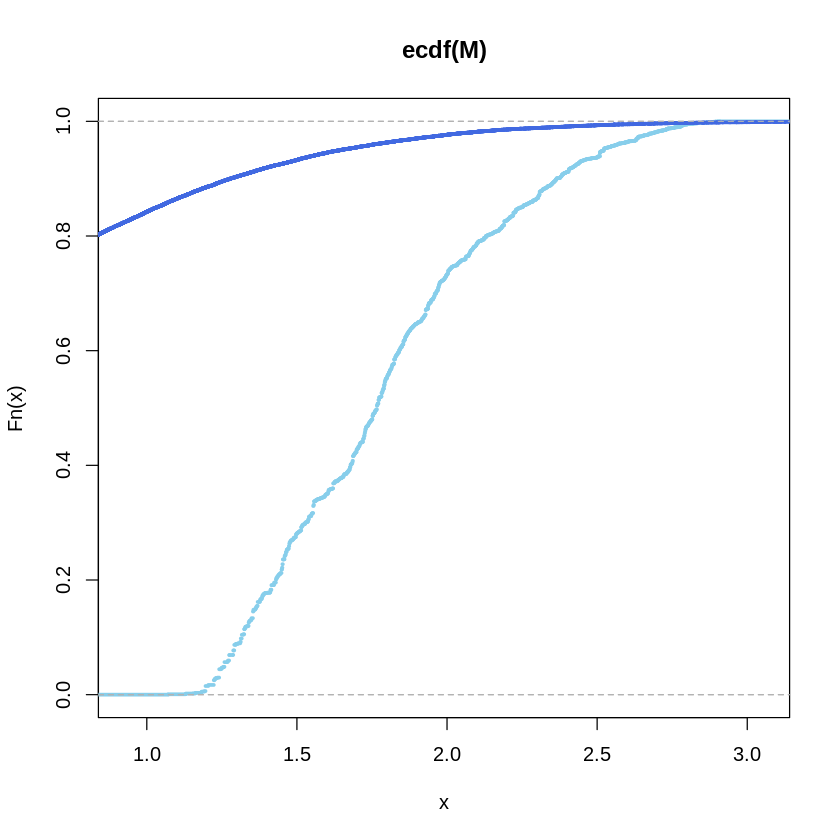

In [ ]:
plot(ecdf(M),col = "skyblue",lwd = 3)
lines(ecdf(y),lwd = 3,type = "s", col = "royalblue")


In [ ]:
f1 = function(x){
  #p = unique(M)
  y = length(which(M <= x))/length(M)
  return(y)
}

In [ ]:
set.seed(1234)
longitud = 10000000
c = rt(longitud, m)
c = c[c>0]
SA = list()
for(i in 1:length(c)){
  u = runif(1, 0, dt(c[i],m))
  if(u*c[i] <= f(c[i])){
    SA[[i]] =  c[i]
  }
}
SA = unlist(SA)

In [ ]:
length(SA)

In [ ]:
LMR = 6000000
z = SA
z = exp(z +12)
summary(z)

In [ ]:
z1 = z -LMR
summary(z1)

In [ ]:
length(which(z1>0))*100/length(SA)

# **Diversos Técnicos**

In [ ]:
M = Te$SA
#Se aplica una transformación de Box Cox para suavizar los datos
#Posteriormente esto puede deshacerse
M = log(M)-6.461

In [ ]:
#Se calculan los whiscklers del box plot y se quitan outliers
l =  boxplot.stats(M)$stats
M= M[M >= l[1] & M <= l[5]]
summary(M)

In [ ]:
#Se calcula por máxima verosimilitud los parámetros de una cauchy
ajuste = fitdistr(M,"t")
ajuste
#Se guardan los degree freedom en la variable m
m = ajuste$estimate["df"]
set.seed(1234)
y <- rt(length(M),df =m)
#Se comparan nuestros datos con la simulación
#La hipótesis alternativa es que la función de distribución o de proabilidad acumulada empírica queda por encima de
ks.test(M,y, alternative = "greater")

In [ ]:
plot(ecdf(M),col = "purple2",lwd = 3)
lines(ecdf(y),lwd = 3,type = "s", col = "purple4")

In [ ]:
f2 = function(x){
  #p = unique(M)
  y = length(which(M <= x))/length(M)
  return(y)
}

In [ ]:
set.seed(1234)
longitud = 1000000
c = rt(longitud, m)
c = c[c>0]
SA = list()
for(i in 1:length(c)){
  u = runif(1, 0, dt(c[i],m))
  if(u*c[i] <= f(c[i])){
    SA[[i]] =  c[i]
  }
}
SA = unlist(SA)

In [ ]:
length(SA)

In [ ]:
LMR = 10000000
z = SA
z = exp(z +6.6461)
summary(z)

In [ ]:
length(which(z1>0))*100/length(SA)